# Problema 10.2 (v) — Diagrama de bifurcaciones

En este inciso representamos las coordenadas de los puntos fijos del truncamiento a dos modos como funciones del tamaño del dominio $L$, indicando en cada tramo si son estables, inestables o puntos silla.

El parámetro usado en los incisos anteriores es

$$
k=\frac{2\pi}{L}.
$$

Por eso aumentar $L$ equivale a disminuir $k$ y debilitar el término disipativo de cuarta derivada. Leeremos el diagrama de izquierda a derecha, es decir, aumentando el tamaño del sistema.

## 1. Ramas de puntos fijos

Del inciso 10.2(iv) tenemos el punto trivial

$$
P_0=(0,0),
$$

que existe para todo $L$, y dos puntos simétricos

$$
P_\pm=
\left(
\pm4\sqrt{(k^2-1)(1-4k^2)},
\;2(k^2-1)
\right).
$$

Reemplazando $k=2\pi/L$:

$$
A_{1,\pm}^*(L)=
\pm4\sqrt{
\left[\left(\frac{2\pi}{L}\right)^2-1\right]
\left[1-4\left(\frac{2\pi}{L}\right)^2\right]
},
$$

$$
A_{2,\pm}^*(L)=
2\left[\left(\frac{2\pi}{L}\right)^2-1\right].
$$

Las ramas no triviales son reales únicamente cuando

$$
2\pi\leq L\leq4\pi.
$$

## 2. Estabilidad que debe marcarse

La clasificación obtenida a partir del Jacobiano es:

| Intervalo de $L$ | $P_0$ | $P_\pm$ |
|---|---|---|
| $L<2\pi$ | estable | no existen |
| $2\pi<L<2\pi\sqrt2$ | silla | nodos estables |
| $2\pi\sqrt2<L<4\pi$ | silla | focos estables |
| $L>4\pi$ | nodo inestable | no existen |

El valor

$$
L=2\pi\sqrt2
$$

no crea ni destruye puntos fijos y tampoco cambia su estabilidad. Solo cambia la forma de aproximación a $P_\pm$: antes es monótona, como nodo; después es oscilatoria, como foco o espiral.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def ramas_no_triviales(L):
    """Devuelve A1+, A1- y A2 de P±; fuera de existencia devuelve NaN."""
    L = np.asarray(L, dtype=float)
    k = 2*np.pi/L
    radicando = (k**2-1)*(1-4*k**2)
    existe = (L >= 2*np.pi) & (L <= 4*np.pi)

    A1p = np.full_like(L, np.nan)
    A2 = np.full_like(L, np.nan)
    A1p[existe] = 4*np.sqrt(np.maximum(radicando[existe], 0))
    A2[existe] = 2*(k[existe]**2-1)
    return A1p, -A1p, A2


L = np.linspace(1.0, 14.0, 1800)
A1p, A1m, A2nt = ramas_no_triviales(L)

Lc1 = 2*np.pi
L_nodo_foco = 2*np.pi*np.sqrt(2)
Lc2 = 4*np.pi


## 3. Diagrama solicitado: $A_1^*$ en función de $L$

En el gráfico usamos:

- azul continuo para el origen estable;
- naranja discontinuo para el origen tipo silla;
- rojo punteado para el origen completamente inestable;
- verde para los puntos no triviales cuando son nodos estables;
- violeta cuando son focos estables.

Las dos ramas no triviales son simétricas porque el sistema es invariante bajo

$$
(a_1,a_2)\mapsto(-a_1,a_2).
$$

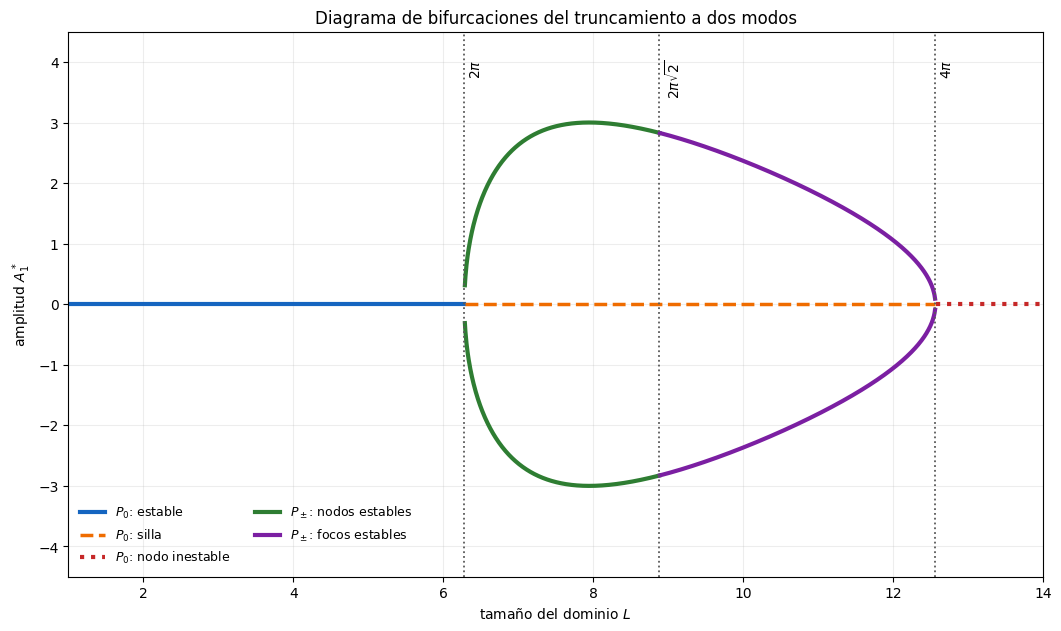

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 6.2), constrained_layout=True)

origen_estable = L < Lc1
origen_silla = (L >= Lc1) & (L < Lc2)
origen_inestable = L >= Lc2
nodos = (L >= Lc1) & (L < L_nodo_foco)
focos = (L >= L_nodo_foco) & (L <= Lc2)

ax.plot(L[origen_estable], np.zeros(origen_estable.sum()),
        color="#1565c0", lw=3, label=r"$P_0$: estable")
ax.plot(L[origen_silla], np.zeros(origen_silla.sum()),
        color="#ef6c00", ls="--", lw=2.5, label=r"$P_0$: silla")
ax.plot(L[origen_inestable], np.zeros(origen_inestable.sum()),
        color="#c62828", ls=":", lw=3, label=r"$P_0$: nodo inestable")

ax.plot(L[nodos], A1p[nodos], color="#2e7d32", lw=3,
        label=r"$P_\pm$: nodos estables")
ax.plot(L[nodos], A1m[nodos], color="#2e7d32", lw=3)
ax.plot(L[focos], A1p[focos], color="#7b1fa2", lw=3,
        label=r"$P_\pm$: focos estables")
ax.plot(L[focos], A1m[focos], color="#7b1fa2", lw=3)

for xcrit, texto in ((Lc1, r"$2\pi$"),
                     (L_nodo_foco, r"$2\pi\sqrt{2}$"),
                     (Lc2, r"$4\pi$")):
    ax.axvline(xcrit, color="0.35", ls=":", lw=1.3)
    ax.text(xcrit+0.06, 4.05, texto, rotation=90, va="top", fontsize=10)

ax.set(xlim=(1, 14), ylim=(-4.5, 4.5),
       xlabel=r"tamaño del dominio $L$", ylabel=r"amplitud $A_1^*$",
       title=r"Diagrama de bifurcaciones del truncamiento a dos modos")
ax.grid(alpha=0.22)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="lower left")
plt.show()


## 4. Primera transición: pitchfork supercrítica en $L=2\pi$

Cuando $L$ se acerca a $2\pi$ desde arriba,

$$
P_\pm\longrightarrow(0,0)=P_0.
$$

Al atravesar ese valor:

- el punto trivial cambia de estable a silla;
- aparecen dos ramas simétricas estables.

Esta es la estructura de una **bifurcación pitchfork supercrítica**. El parámetro efectivo puede pensarse como

$$
\mu=1-k^2=1-\left(\frac{2\pi}{L}\right)^2,
$$

que cambia de signo en $L=2\pi$.

## 5. ¿Qué ocurre en $L=4\pi$?

En el gráfico de $A_1^*$ las ramas regresan a cero, pero esto puede resultar engañoso. En realidad,

$$
P_\pm\longrightarrow\left(0,-\frac32\right),
$$

mientras que

$$
P_0=(0,0).
$$

Por lo tanto, las ramas no chocan nuevamente con el origen en el espacio completo $(a_1,a_2)$. Parecen hacerlo solamente porque el diagrama solicitado proyecta toda la información sobre $a_1$.

Exactamente en $L=4\pi$, equivalente a $k=1/2$, el sistema truncado satisface

$$
a_1=0,
\qquad
a_2\ \text{arbitrario},
$$

y aparece una línea degenerada de equilibrios. No es una bifurcación pitchfork ordinaria; es una degeneración particular del truncamiento a dos modos.

## 6. Segunda coordenada de las ramas

El siguiente gráfico no es estrictamente pedido por el enunciado, pero evita interpretar mal el extremo $L=4\pi$. Muestra que las ramas $P_\pm$ parten del origen en $L=2\pi$ y terminan en $A_2^*=-3/2$.

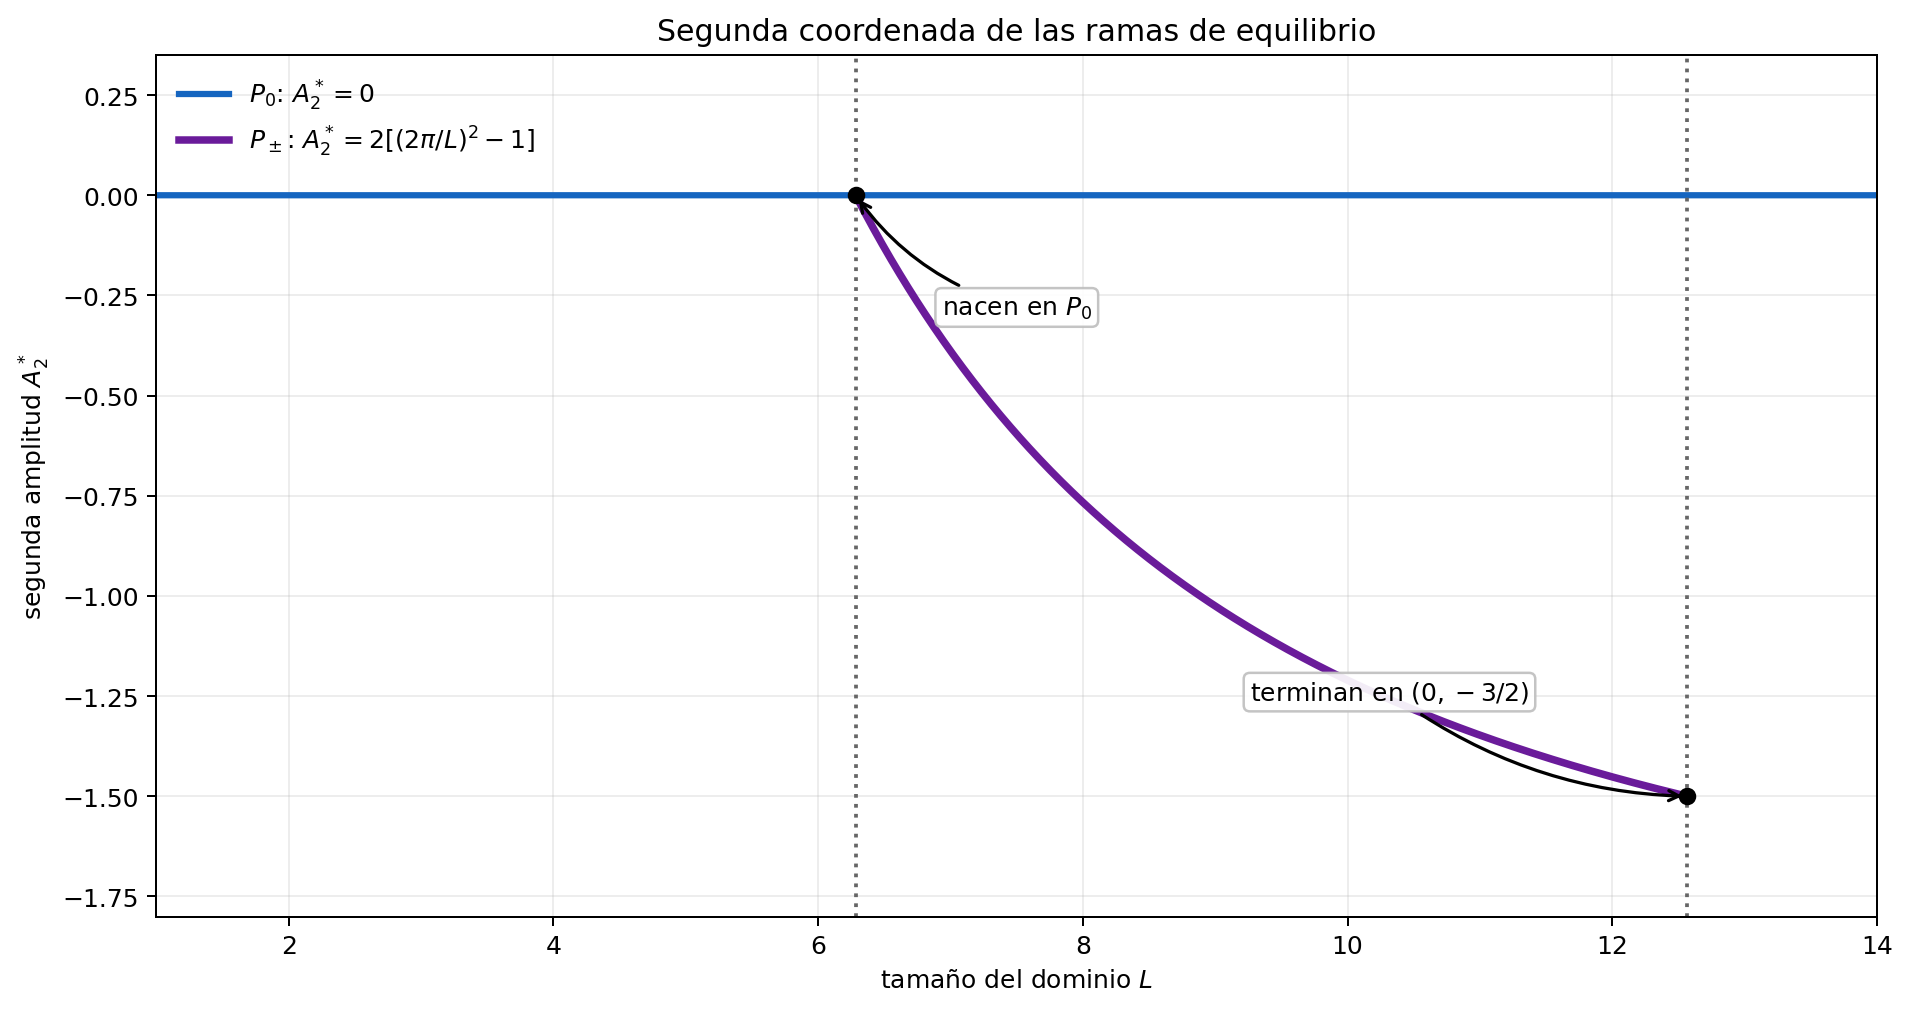

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)

ax.plot(L, np.zeros_like(L), color="#1565c0", lw=2.5,
        label=r"$P_0$: $A_2^*=0$")
ax.plot(L, A2nt, color="#6a1b9a", lw=3,
        label=r"$P_\pm$: $A_2^*=2[(2\pi/L)^2-1]$")

ax.scatter([Lc1, Lc2], [0, -1.5], color="black", zorder=4)
estilo_texto = {"boxstyle": "round,pad=0.25", "fc": "white",
                "ec": "0.75", "alpha": 0.92}
ax.annotate(r"nacen en $P_0$", xy=(Lc1, 0), xytext=(Lc1+0.65, -0.28),
            ha="left", va="center", bbox=estilo_texto,
            arrowprops={"arrowstyle": "->", "lw": 1.3,
                        "connectionstyle": "arc3,rad=-0.18"})
ax.annotate(r"terminan en $(0,-3/2)$", xy=(Lc2, -1.5),
            xytext=(Lc2-2.25, -1.24), ha="center", va="center",
            bbox=estilo_texto,
            arrowprops={"arrowstyle": "->", "lw": 1.3,
                        "connectionstyle": "arc3,rad=0.16"})
ax.axvline(Lc1, color="0.4", ls=":")
ax.axvline(Lc2, color="0.4", ls=":")

ax.set(xlim=(1, 14), ylim=(-1.8, 0.35),
       xlabel=r"tamaño del dominio $L$", ylabel=r"segunda amplitud $A_2^*$",
       title=r"Segunda coordenada de las ramas de equilibrio")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.show()


## 7. Comprobación mediante autovalores

Como control, evaluamos numéricamente el Jacobiano en algunos valores representativos de $L$. Los signos y la presencia de partes imaginarias deben coincidir con la tabla de estabilidad.

In [5]:
def jacobiano(A1, A2, L):
    k = 2*np.pi/L
    return np.array([
        [(1-k**2)+A2/2, A1/2],
        [-A1, 4*(1-4*k**2)],
    ])


for L_prueba in (1.8*np.pi, 2.2*np.pi, 3*np.pi, 4.2*np.pi):
    A1p_, A1m_, A2_ = ramas_no_triviales(np.array([L_prueba]))
    eig0 = np.linalg.eigvals(jacobiano(0, 0, L_prueba))
    print(f"L/pi={L_prueba/np.pi:.2f}: P0 -> {eig0}")
    if np.isfinite(A1p_[0]):
        eigp = np.linalg.eigvals(jacobiano(A1p_[0], A2_[0], L_prueba))
        print(f"             P± -> {eigp}")


L/pi=1.80: P0 -> [ -0.2345679  -15.75308642]
L/pi=2.20: P0 -> [ 0.17355372 -9.2231405 ]
             P± -> [-0.36125738 -8.86188312]
L/pi=3.00: P0 -> [ 0.55555556 -3.11111111]
             P± -> [-1.55555556+1.01835015j -1.55555556-1.01835015j]
L/pi=4.20: P0 -> [0.77324263 0.37188209]


## Conclusión

El diagrama muestra dos cambios cualitativos principales:

1. En $L=2\pi$ ocurre una bifurcación pitchfork supercrítica: el origen pierde estabilidad y nacen dos soluciones no triviales estables.
2. En $L=4\pi$ aparece una degeneración del modelo truncado, donde existe una línea de puntos fijos con $a_1=0$.

Entre ambos valores, las soluciones no triviales siguen siendo estables. En $L=2\pi\sqrt2$ cambian de nodos a focos, lo cual modifica la manera en que las trayectorias convergen, pero no constituye una nueva bifurcación de puntos fijos.

Este análisis también explica por qué el truncamiento a dos modos funciona bien cerca de la primera inestabilidad pero deja de ser una descripción suficiente cuando el dominio continúa aumentando y entran en juego modos adicionales.